# Notebook 12: Survey Results Analysis

**Purpose:** Analyse user study survey data and generate metrics for Chapter 5 (Results and Discussion)

**Data Source:** `response_1772367263480.json` - Raw Redis export containing all participant sessions

**Metrics Generated:**
- H1: Engagement metrics (session duration, preference)
- H2: Trust metrics (Likert scores, trust preference)
- H3: Economic metrics (purchases, spending preference)
- Participant demographics and archetype distribution

---

## Cell 1: Setup and Imports

Import required libraries for data analysis and visualisation.

In [1]:
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

# Set style for thesis-quality figures
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

# Create figures directory
import os
os.makedirs('figures', exist_ok=True)

print("Libraries loaded successfully")

Libraries loaded successfully


## Cell 2: Load Raw Data

Load the raw Redis export containing all participant sessions (complete and incomplete).

In [2]:
# Load raw Redis export
SURVEY_FILE = "response_1772367263480.json"

with open(SURVEY_FILE, 'r') as f:
    raw_data = json.load(f)

print("RAW DATA SUMMARY")
print("="*60)
print(f"Export timestamp: {raw_data.get('exported_at')}")
print(f"Total participants in export: {len(raw_data.get('participants', {}))}")

RAW DATA SUMMARY
Export timestamp: 2026-02-28T09:45:12.204489
Total participants in export: 28


## Cell 3: Data Cleaning - Identify Complete vs Incomplete Participants

The raw export contains both complete and incomplete sessions. We apply the following inclusion criteria:

**Inclusion Criteria:**
1. Participant has `study_completed_at` timestamp (completed both conditions)
2. Participant has valid `condition_durations` for both A and B
3. Participant has submitted `final_comparison_survey`
4. Neither condition duration is 0 or undefined (technical failure)

**Exclusion Criteria:**
1. Sessions marked as `incomplete`
2. Sessions with only `full_session` or `conditions` keys (pilot/test sessions)
3. P118: Condition A duration is 0 (localStorage bug)

In [3]:
# Examine participant data structure
participants = raw_data.get('participants', {})

complete_participants = []
incomplete_participants = []
excluded_technical = []

print("DATA CLEANING PROCESS")
print("="*60)

for pid, pdata in participants.items():
    # Check for completion markers
    has_completion = 'study_completed_at' in pdata
    has_durations = 'condition_durations' in pdata
    has_survey = 'final_comparison_survey' in pdata
    is_incomplete = 'incomplete' in pdata
    
    if is_incomplete:
        incomplete_participants.append(pid)
        continue
    
    if has_completion and has_durations and has_survey:
        durations = pdata['condition_durations']
        dur_a = durations.get('A', 0)
        dur_b = durations.get('B', 0)
        
        # Check for technical failures (0 duration)
        if dur_a == 0 or dur_b == 0:
            excluded_technical.append({
                'pid': pid,
                'reason': f'Zero duration (A={dur_a}s, B={dur_b}s)'
            })
            continue
        
        complete_participants.append(pid)
    else:
        incomplete_participants.append(pid)

print(f"\nTotal in raw export: {len(participants)}")
print(f"Complete participants: {len(complete_participants)}")
print(f"Incomplete/dropped: {len(incomplete_participants)}")
print(f"Excluded (technical): {len(excluded_technical)}")

print(f"\nIncomplete participant IDs: {incomplete_participants}")
print(f"\nTechnical exclusions:")
for exc in excluded_technical:
    print(f"  {exc['pid']}: {exc['reason']}")

DATA CLEANING PROCESS

Total in raw export: 28
Complete participants: 15
Incomplete/dropped: 12
Excluded (technical): 1

Incomplete participant IDs: ['P002', 'P006', 'P003', 'P055', 'P095', 'P102', 'P025', 'P103', 'P065', 'P075', 'P049', 'P013']

Technical exclusions:
  P118: Zero duration (A=0s, B=237s)


## Cell 4: Extract Clean Dataset

Extract the 15 useful participants into a structured DataFrame for analysis.

In [4]:
# Extract data for complete participants
clean_data = []

for pid in complete_participants:
    pdata = participants[pid]
    durations = pdata['condition_durations']
    survey = pdata['final_comparison_survey']
    
    # Extract session data if available
    full_session = pdata.get('full_session', {})
    session_data = full_session.get('session_data', {}) if full_session else {}
    
    clean_data.append({
        'id': pid,
        'cond_a_sec': durations.get('A', 0),
        'cond_b_sec': durations.get('B', 0),
        'preferred': survey.get('preferred_version', '').capitalize(),
        'more_engaging': survey.get('more_engaging', '').capitalize(),
        'more_trustworthy': survey.get('more_trustworthy', '').capitalize(),
        'would_spend_more': survey.get('would_spend_more', '').capitalize(),
        'would_recommend': survey.get('would_recommend', '').capitalize(),
        'ai_score': survey.get('ai_better_than_traditional', 0),
        'blockchain_score': survey.get('blockchain_added_value', 0),
        'archetype': session_data.get('archetype', 'unknown'),
        'interaction_count': session_data.get('interaction_count', 0),
        'total_spent_points': session_data.get('total_spent_points', 0),
        'relationship_score': session_data.get('relationship_score', 50),
        'memorable_moment': survey.get('memorable_moment', ''),
        'biggest_difference': survey.get('biggest_difference', ''),
        'additional_feedback': survey.get('additional_feedback', '')
    })

df = pd.DataFrame(clean_data)

print("CLEANED DATASET")
print("="*60)
print(f"Total useful participants: {len(df)}")
print(f"\nParticipant IDs: {df['id'].tolist()}")
print(f"\nNote: Non-consecutive IDs (P001-P120) due to pilot testing and technical validation sessions")
df[['id', 'cond_a_sec', 'cond_b_sec', 'preferred', 'ai_score', 'blockchain_score']]

CLEANED DATASET
Total useful participants: 15

Participant IDs: ['P001', 'P116', 'P080', 'P043', 'P079', 'P109', 'P047', 'P117', 'P018', 'P005', 'P034', 'P093', 'P120', 'P119', 'P011']

Note: Non-consecutive IDs (P001-P120) due to pilot testing and technical validation sessions


,id,cond_a_sec,cond_b_sec,preferred,ai_score,blockchain_score
0,P001,139,568,Beta,5,5
1,P116,105,459,Beta,5,4
2,P080,397,1081,Alpha,2,5
3,P043,388,429,Alpha,1,1
4,P079,323,333,Alpha,2,2
5,P109,366,685,Alpha,1,1
6,P047,487,1085,Beta,4,3
7,P117,149,549,Beta,5,4
8,P018,278,322,Beta,4,3
9,P005,102,350,Beta,5,5


## Cell 5: Participant Flow Statistics (Table 5.6)

Generate participant flow statistics for Chapter 5.

In [5]:
# Participant flow data
total_registrations = len(participants)
completed = len(complete_participants)
excluded = len(excluded_technical)
useful = len(df)
dropouts = len(incomplete_participants)

participant_flow = {
    "Total Registrations": total_registrations,
    "Completed Both Conditions": completed + excluded,
    "Excluded (technical issue)": excluded,
    "Useful Participants": useful,
    "Dropouts (incomplete)": dropouts
}

print("="*60)
print("TABLE 5.6: PARTICIPANT FLOW")
print("="*60)
for stage, count in participant_flow.items():
    pct = (count / total_registrations) * 100
    print(f"{stage:35s}: {count:3d} ({pct:.0f}%)")
print("="*60)
print(f"\nCompletion rate: {useful/total_registrations*100:.1f}%")
print(f"Dropout rate: {dropouts/total_registrations*100:.1f}%")

TABLE 5.6: PARTICIPANT FLOW
Total Registrations                :  28 (100%)
Completed Both Conditions          :  16 (57%)
Excluded (technical issue)         :   1 (4%)
Useful Participants                :  15 (54%)
Dropouts (incomplete)              :  12 (43%)

Completion rate: 53.6%
Dropout rate: 42.9%


## Cell 6: H1 - Engagement Metrics (Session Duration) - Table 5.7

Calculate session duration statistics and test H1 hypothesis (target: +15% duration).

In [6]:
# Session duration analysis
print("="*60)
print("H1: ENGAGEMENT - SESSION DURATION ANALYSIS")
print("="*60)

# Calculate statistics
alpha_total = df['cond_a_sec'].sum()
beta_total = df['cond_b_sec'].sum()
alpha_mean = df['cond_a_sec'].mean()
beta_mean = df['cond_b_sec'].mean()

duration_increase = ((beta_mean - alpha_mean) / alpha_mean) * 100

print(f"\nCondition A (Alpha) - Traditional NPC:")
print(f"  Total time: {alpha_total} seconds")
print(f"  Average: {alpha_mean:.0f} seconds ({alpha_mean/60:.1f} minutes)")

print(f"\nCondition B (Beta) - AI NPC:")
print(f"  Total time: {beta_total} seconds")
print(f"  Average: {beta_mean:.0f} seconds ({beta_mean/60:.1f} minutes)")

print(f"\n" + "="*60)
print(f"DURATION INCREASE: +{duration_increase:.0f}%")
print(f"H1 Target: +15% duration")
print(f"H1 Result: {'SUPPORTED' if duration_increase >= 15 else 'NOT SUPPORTED'}")
print("="*60)

H1: ENGAGEMENT - SESSION DURATION ANALYSIS

Condition A (Alpha) - Traditional NPC:
  Total time: 4292 seconds
  Average: 286 seconds (4.8 minutes)

Condition B (Beta) - AI NPC:
  Total time: 8614 seconds
  Average: 574 seconds (9.6 minutes)

DURATION INCREASE: +101%
H1 Target: +15% duration
H1 Result: SUPPORTED


## Cell 7: H1 - Engagement Preference (Table 5.8)

Calculate preference statistics from the final comparison survey.

In [7]:
# Preference analysis
print("="*60)
print("H1: ENGAGEMENT - PREFERENCE ANALYSIS")
print("="*60)

total = len(df)

# Overall preference
pref_counts = df['preferred'].value_counts()
beta_pref = pref_counts.get('Beta', 0)
alpha_pref = pref_counts.get('Alpha', 0)

# More engaging
engaging_counts = df['more_engaging'].value_counts()

# Would recommend
recommend_counts = df['would_recommend'].value_counts()

print(f"\nOverall Preference (n={total}):")
print(f"  Beta (AI NPC):        {beta_pref} ({beta_pref/total*100:.0f}%)")
print(f"  Alpha (Traditional):  {alpha_pref} ({alpha_pref/total*100:.0f}%)")

print(f"\nMore Engaging:")
for val, count in engaging_counts.items():
    print(f"  {val}: {count} ({count/total*100:.0f}%)")

print(f"\nWould Recommend:")
for val, count in recommend_counts.items():
    print(f"  {val}: {count} ({count/total*100:.0f}%)")

print(f"\n" + "="*60)
print(f"BETA PREFERENCE: {beta_pref/total*100:.0f}%")
print(f"H1 Result: {'SUPPORTED' if beta_pref > alpha_pref else 'NOT SUPPORTED'}")
print("="*60)

H1: ENGAGEMENT - PREFERENCE ANALYSIS

Overall Preference (n=15):
  Beta (AI NPC):        9 (60%)
  Alpha (Traditional):  6 (40%)

More Engaging:
  Beta: 10 (67%)
  Alpha: 4 (27%)
  Same: 1 (7%)

Would Recommend:
  Beta: 8 (53%)
  Alpha: 3 (20%)
  Neither: 3 (20%)
  Both: 1 (7%)

BETA PREFERENCE: 60%
H1 Result: SUPPORTED


## Cell 8: H2 - Trust Metrics (Likert Scores) - Tables 5.9, 5.10

Calculate AI and Blockchain perception scores.

In [8]:
# Trust/perception analysis
print("="*60)
print("H2: TRUST - LIKERT SCORE ANALYSIS")
print("="*60)

ai_mean = df['ai_score'].mean()
ai_std = df['ai_score'].std()
blockchain_mean = df['blockchain_score'].mean()
blockchain_std = df['blockchain_score'].std()

print(f"\n'AI Better Than Traditional' (1-5 Likert):")
print(f"  Mean: {ai_mean:.2f}")
print(f"  Std:  {ai_std:.2f}")
print(f"  Scores: {df['ai_score'].tolist()}")

print(f"\n'Blockchain Added Value' (1-5 Likert):")
print(f"  Mean: {blockchain_mean:.2f}")
print(f"  Std:  {blockchain_std:.2f}")
print(f"  Scores: {df['blockchain_score'].tolist()}")

# Score distribution (polarisation analysis)
ai_low = len(df[df['ai_score'] <= 2])
ai_neutral = len(df[df['ai_score'] == 3])
ai_high = len(df[df['ai_score'] >= 4])

print(f"\nScore Distribution (Polarisation Analysis):")
print(f"  AI Low (1-2):     {ai_low} ({ai_low/total*100:.0f}%)")
print(f"  AI Neutral (3):   {ai_neutral} ({ai_neutral/total*100:.0f}%)")
print(f"  AI High (4-5):    {ai_high} ({ai_high/total*100:.0f}%)")

# Trust preference
trust_counts = df['more_trustworthy'].value_counts()
print(f"\nMore Trustworthy:")
for val, count in trust_counts.items():
    print(f"  {val}: {count} ({count/total*100:.0f}%)")

H2: TRUST - LIKERT SCORE ANALYSIS

'AI Better Than Traditional' (1-5 Likert):
  Mean: 3.20
  Std:  1.57
  Scores: [5, 5, 2, 1, 2, 1, 4, 5, 4, 5, 1, 2, 4, 4, 3]

'Blockchain Added Value' (1-5 Likert):
  Mean: 3.13
  Std:  1.46
  Scores: [5, 4, 5, 1, 2, 1, 3, 4, 3, 5, 1, 2, 3, 4, 4]

Score Distribution (Polarisation Analysis):
  AI Low (1-2):     6 (40%)
  AI Neutral (3):   1 (7%)
  AI High (4-5):    8 (53%)

More Trustworthy:
  Beta: 7 (47%)
  Alpha: 5 (33%)
  Same: 3 (20%)


## Cell 9: H2 - Trust by Preference Group (Polarisation Analysis)

Analyse how AI/Blockchain scores differ between those who preferred Alpha vs Beta.

In [9]:
# Trust scores by preference group
print("="*60)
print("TRUST SCORES BY PREFERENCE GROUP")
print("="*60)

beta_group = df[df['preferred'] == 'Beta']
alpha_group = df[df['preferred'] == 'Alpha']

print(f"\nParticipants who preferred Beta (n={len(beta_group)}):")
print(f"  Avg AI Score:         {beta_group['ai_score'].mean():.2f}")
print(f"  Avg Blockchain Score: {beta_group['blockchain_score'].mean():.2f}")

print(f"\nParticipants who preferred Alpha (n={len(alpha_group)}):")
print(f"  Avg AI Score:         {alpha_group['ai_score'].mean():.2f}")
print(f"  Avg Blockchain Score: {alpha_group['blockchain_score'].mean():.2f}")

ai_diff = beta_group['ai_score'].mean() - alpha_group['ai_score'].mean()
print(f"\n" + "="*60)
print("POLARISATION FINDING:")
print(f"  Beta-preferrers rate AI {ai_diff:.2f} points higher than Alpha-preferrers")
print(f"  This indicates strong individual differences in AI attitudes")
print("="*60)

TRUST SCORES BY PREFERENCE GROUP

Participants who preferred Beta (n=9):
  Avg AI Score:         4.33
  Avg Blockchain Score: 3.89

Participants who preferred Alpha (n=6):
  Avg AI Score:         1.50
  Avg Blockchain Score: 2.00

POLARISATION FINDING:
  Beta-preferrers rate AI 2.83 points higher than Alpha-preferrers
  This indicates strong individual differences in AI attitudes


## Cell 10: H3 - Economic Metrics

Analyse economic behaviour from session data.

In [10]:
# Economic analysis
print("="*60)
print("H3: ECONOMIC - SPENDING ANALYSIS")
print("="*60)

# Spending preference
spend_counts = df['would_spend_more'].value_counts()
print(f"\nWould Spend More With:")
for val, count in spend_counts.items():
    print(f"  {val}: {count} ({count/total*100:.0f}%)")

# Actual spending from session data
print(f"\nActual Spending (from Beta sessions):")
print(f"  Total points spent: {df['total_spent_points'].sum()}")
print(f"  Average per participant: {df['total_spent_points'].mean():.0f} points")
print(f"  Max spent: {df['total_spent_points'].max()} points")

# Top spenders
top_spenders = df.nlargest(5, 'total_spent_points')[['id', 'archetype', 'total_spent_points', 'interaction_count']]
print(f"\nTop 5 Spenders:")
print(top_spenders.to_string(index=False))

H3: ECONOMIC - SPENDING ANALYSIS

Would Spend More With:
  Beta: 7 (47%)
  Alpha: 5 (33%)
  Same: 2 (13%)
  Neither: 1 (7%)

Actual Spending (from Beta sessions):
  Total points spent: 15760
  Average per participant: 1051 points
  Max spent: 1825 points

Top 5 Spenders:
  id        archetype  total_spent_points  interaction_count
P011 engaged_beginner                1825                 10
P001 engaged_beginner                1725                 17
P119          spender                1715                 19
P093    trophy_hunter                1600                 13
P109 engaged_beginner                1345                 25


## Cell 10B: H3 - Purchase Behaviour Breakdown

In [19]:

# Cell 10B: Purchase Behaviour Breakdown (Table 5.12)

from collections import Counter

# Display name mapping for thesis presentation
ITEM_DISPLAY = {
    'hint':           'Hint',
    'premium_hint':   'Solution (Premium Hint)',
    'scroll':         'Gate Scroll',
    'nft_common':     "NFT Common (Merchant's Favor)",
    'nft_rare':       "NFT Rare (Shadow's Blessing)",
    'pol_conversion': 'POL Conversion (POL → Points)'
}

# Presentation order for Table 5.12
ITEM_ORDER = ['hint', 'scroll', 'premium_hint', 'nft_rare', 'nft_common', 'pol_conversion']

# ----------------------------------------------------------
# 1. Extract confirmed purchases from conversation history
# ----------------------------------------------------------
item_counts = Counter()
participant_purchases = {}

for pid in complete_participants:
    pdata = participants[pid]
    conv = (pdata
            .get('full_session', {})
            .get('session_data', {})
            .get('conversation_history', []))

    pid_items = Counter()
    for msg in conv:
        if (msg.get('purchase_state') == 'confirmed'
                and msg.get('purchase_metadata')):
            item = msg['purchase_metadata'].get('item', 'unknown')
            pid_items[item] += 1
            item_counts[item] += 1

    participant_purchases[pid] = dict(pid_items)

total_purchases = sum(item_counts.values())

# ----------------------------------------------------------
# 2. Print Table Purchase Behaviour (Beta Condition)
# ----------------------------------------------------------
print("=" * 60)
print("PURCHASE BEHAVIOUR (BETA CONDITION, n=15)")
print("=" * 60)
print(f"\n{'Item':<40s} {'Count':>6} {'%':>6}")
print("-" * 54)

for item_key in ITEM_ORDER:
    count = item_counts.get(item_key, 0)
    pct = (count / total_purchases * 100) if total_purchases else 0
    display = ITEM_DISPLAY.get(item_key, item_key)
    print(f"  {display:<38s} {count:>5}  {pct:>5.0f}%")

print("-" * 54)
print(f"  {'Total':<38s} {total_purchases:>5}  {100:>5.0f}%")

# ----------------------------------------------------------
# 3. Per-participant purchase detail
# ----------------------------------------------------------
print(f"\n\n{'=' * 70}")
print("PER-PARTICIPANT PURCHASE DETAIL")
print(f"{'=' * 70}")
print(f"{'PID':<7} {'Hint':>5} {'Soln':>5} {'Scroll':>7} "
      f"{'NFTc':>5} {'NFTr':>5} {'POLc':>5} {'Total':>6}")
print("-" * 50)

for pid in complete_participants:
    pp = participant_purchases.get(pid, {})
    h  = pp.get('hint', 0)
    s  = pp.get('premium_hint', 0)
    sc = pp.get('scroll', 0)
    nc = pp.get('nft_common', 0)
    nr = pp.get('nft_rare', 0)
    pc = pp.get('pol_conversion', 0)
    t  = h + s + sc + nc + nr + pc
    print(f"{pid:<7} {h:>5} {s:>5} {sc:>7} {nc:>5} {nr:>5} {pc:>5} {t:>6}")

# Totals row
vals = [item_counts.get(k, 0) for k in
        ['hint', 'premium_hint', 'scroll', 'nft_common', 'nft_rare', 'pol_conversion']]
print("-" * 50)
print(f"{'TOTAL':<7} {vals[0]:>5} {vals[1]:>5} {vals[2]:>7} "
      f"{vals[3]:>5} {vals[4]:>5} {vals[5]:>5} {sum(vals):>6}")

# ----------------------------------------------------------
# 4. Summary statistics for thesis
# ----------------------------------------------------------
nft_total = item_counts.get('nft_common', 0) + item_counts.get('nft_rare', 0)
points_items = (item_counts.get('hint', 0)
                + item_counts.get('premium_hint', 0)
                + item_counts.get('scroll', 0))
buyers = sum(1 for pid in complete_participants
             if sum(participant_purchases.get(pid, {}).values()) > 0)

print(f"\n\n{'=' * 60}")
print("PURCHASE SUMMARY STATISTICS")
print(f"{'=' * 60}")
print(f"  Total confirmed purchases:     {total_purchases}")
print(f"  Participants who purchased:     {buyers}/{len(complete_participants)}"
      f" ({buyers/len(complete_participants)*100:.0f}%)")
print(f"  Points-based item purchases:    {points_items}"
      f" ({points_items/total_purchases*100:.0f}%)")
print(f"  NFT purchases (blockchain):     {nft_total}"
      f" ({nft_total/total_purchases*100:.0f}%)")
print(f"  POL conversions:                {item_counts.get('pol_conversion', 0)}"
      f" ({item_counts.get('pol_conversion', 0)/total_purchases*100:.0f}%)")
print(f"  Avg purchases per participant:  {total_purchases/len(complete_participants):.1f}")

PURCHASE BEHAVIOUR (BETA CONDITION, n=15)

Item                                      Count      %
------------------------------------------------------
  Hint                                      33     36%
  Gate Scroll                               27     29%
  Solution (Premium Hint)                   15     16%
  NFT Rare (Shadow's Blessing)               6      7%
  NFT Common (Merchant's Favor)              4      4%
  POL Conversion (POL → Points)              7      8%
------------------------------------------------------
  Total                                     92    100%


PER-PARTICIPANT PURCHASE DETAIL
PID      Hint  Soln  Scroll  NFTc  NFTr  POLc  Total
--------------------------------------------------
P001        3     1       4     0     1     0      9
P116        2     3       1     0     1     1      8
P080        1     0       1     1     1     0      4
P043        4     2       0     0     0     1      7
P079        2     0       4     1     1     0      8
P109

## Cell 11: Archetype Distribution

Analyse player archetype distribution from the clustering system.

In [11]:
# Archetype analysis
print("="*60)
print("PLAYER ARCHETYPE DISTRIBUTION")
print("="*60)

archetype_counts = df['archetype'].value_counts()
print(f"\nArchetype Distribution (n={total}):")
for arch, count in archetype_counts.items():
    print(f"  {arch}: {count} ({count/total*100:.0f}%)")

# Archetype vs preference
print(f"\nArchetype × Preference:")
cross = pd.crosstab(df['archetype'], df['preferred'])
print(cross)

PLAYER ARCHETYPE DISTRIBUTION

Archetype Distribution (n=15):
  engaged_beginner: 7 (47%)
  spender: 4 (27%)
  casual_veteran: 2 (13%)
  achievement_hunter: 1 (7%)
  trophy_hunter: 1 (7%)

Archetype × Preference:
preferred           Alpha  Beta
archetype                      
achievement_hunter      1     0
casual_veteran          0     2
engaged_beginner        3     4
spender                 1     3
trophy_hunter           1     0


## Cell 12: Qualitative Feedback

Extract and analyse free-text responses for thematic insights.

In [12]:
# Qualitative feedback analysis
print("="*60)
print("QUALITATIVE FEEDBACK (THEMATIC ANALYSIS)")
print("="*60)

# Filter for substantive responses only:
# - More than 10 characters
# - More than 2 words (filters out 'the', 'as', etc.)
def is_substantive(text):
    if pd.isna(text) or not isinstance(text, str):
        return False
    text = text.strip()
    return len(text) > 10 and len(text.split()) > 2

memorable = df[df['memorable_moment'].apply(is_substantive)][['id', 'preferred', 'memorable_moment']]
differences = df[df['biggest_difference'].apply(is_substantive)][['id', 'preferred', 'biggest_difference']]
feedback = df[df['additional_feedback'].apply(is_substantive)][['id', 'preferred', 'additional_feedback']]

print(f"\nMemorable Moments ({len(memorable)} substantive responses):")
for _, row in memorable.iterrows():
    print(f"  Participant {row['id'].replace('P', '')} ({row['preferred']}):")
    print(f"    \"{row['memorable_moment']}\"")

print(f"\nBiggest Differences ({len(differences)} substantive responses):")
for _, row in differences.iterrows():
    print(f"  Participant {row['id'].replace('P', '')} ({row['preferred']}):")
    print(f"    \"{row['biggest_difference']}\"")

print(f"\nAdditional Feedback ({len(feedback)} substantive responses):")
for _, row in feedback.iterrows():
    print(f"  Participant {row['id'].replace('P', '')} ({row['preferred']}):")
    print(f"    \"{row['additional_feedback']}\"")

# Thematic summary
print(f"\n" + "="*60)
print("EMERGENT THEMES")
print("="*60)
print("\nFrom Alpha-preferring participants:")
print("  1. Trust damage: AI provided incorrect discount/pricing information")
print("  2. Cognitive overload: Conversational interface felt overwhelming")
print("  3. Latency concerns: AI responses perceived as slowing gameplay")
print("  4. Technical issues: Firefox text input bug reported")
print("\nFrom Beta-preferring participants:")
print("  1. Puzzle difficulty noted (not NPC-related)")
print("  2. Price differences observed between conditions")

QUALITATIVE FEEDBACK (THEMATIC ANALYSIS)

Memorable Moments (5 substantive responses):
  Participant 080 (Alpha):
    "When I figured out the gameplay and when I won game A"
  Participant 043 (Alpha):
    "The shop broke completely after I made a purchase I didn't have the balance for. "
  Participant 109 (Alpha):
    "When the ai scammed me"
  Participant 018 (Beta):
    "Inability to answer a riddle without multiple guesses "
  Participant 034 (Alpha):
    "god dam AI told he gave me a discount but actually didn't"

Biggest Differences (3 substantive responses):
  Participant 080 (Alpha):
    "Version B was more confusing and overwhelming"
  Participant 109 (Alpha):
    "ai slowed down gameplay "
  Participant 034 (Alpha):
    "the AI yaps but honestly it made no difference, its still a amatter of luck "

Additional Feedback (2 substantive responses):
  Participant 043 (Alpha):
    "I'm on firefox, and these fields don't work unless I copy-paste. It's pretty annoying."
  Participant 

## Cell 13: Visualisation - Session Duration Comparison

Generate session duration comparison figure for Chapter 5.

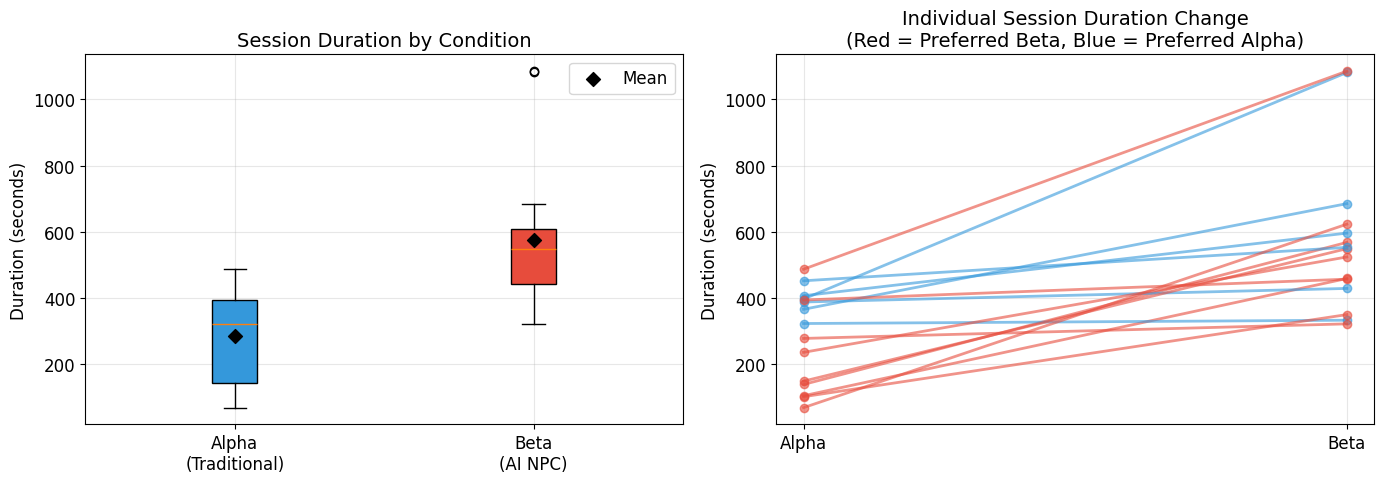

Figure saved: figures/fig_5_2_session_duration.png


In [13]:
# Session duration visualisation
# Note: Using explicit list conversion to avoid numpy/matplotlib compatibility issues

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Box plot comparison
ax1 = axes[0]
box_data = [list(df['cond_a_sec']), list(df['cond_b_sec'])]
bp = ax1.boxplot(box_data, labels=['Alpha\n(Traditional)', 'Beta\n(AI NPC)'], patch_artist=True)
bp['boxes'][0].set_facecolor('#3498db')
bp['boxes'][1].set_facecolor('#e74c3c')
ax1.set_title('Session Duration by Condition')
ax1.set_ylabel('Duration (seconds)')

# Add mean markers
ax1.scatter([1, 2], [float(alpha_mean), float(beta_mean)], color='black', marker='D', s=50, zorder=5, label='Mean')
ax1.legend()

# Paired line plot
ax2 = axes[1]
for idx, row in df.iterrows():
    color = '#e74c3c' if row['preferred'] == 'Beta' else '#3498db'
    ax2.plot([0, 1], [float(row['cond_a_sec']), float(row['cond_b_sec'])], marker='o', color=color, alpha=0.6, linewidth=2)
ax2.set_xticks([0, 1])
ax2.set_xticklabels(['Alpha', 'Beta'])
ax2.set_ylabel('Duration (seconds)')
ax2.set_title('Individual Session Duration Change\n(Red = Preferred Beta, Blue = Preferred Alpha)')

plt.tight_layout()
plt.savefig('figures/fig_5_2_session_duration.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figure saved: figures/fig_5_2_session_duration.png")

## Cell 14: Visualisation - Preference and Likert Scores

Generate preference and perception score visualisations.

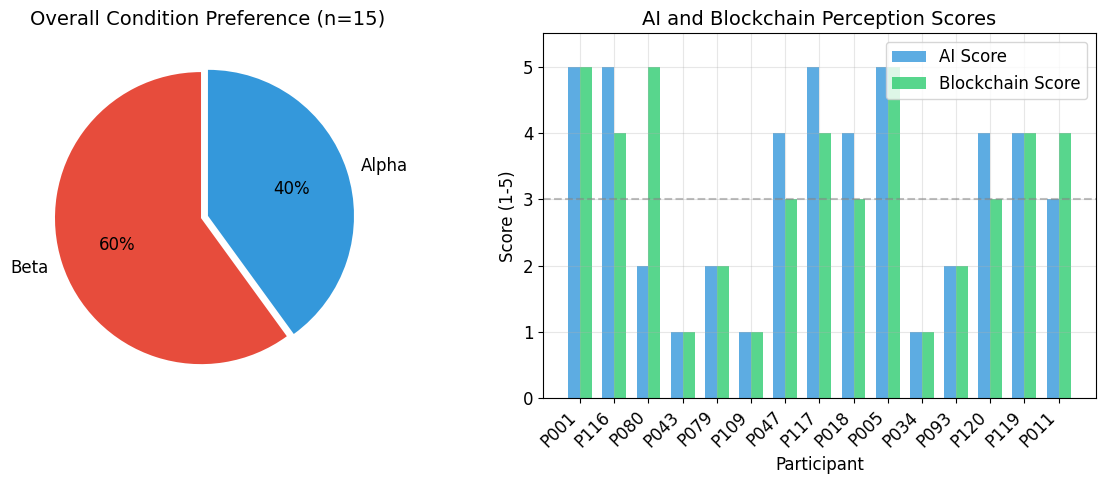

Figure saved: figures/fig_5_3_preference_scores.png


In [14]:
# Preference and scores visualisation
# Note: Using explicit list/float conversion to avoid numpy/matplotlib compatibility issues

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Preference pie chart
ax1 = axes[0]
pref_data = df['preferred'].value_counts()
colors = ['#e74c3c' if x == 'Beta' else '#3498db' for x in pref_data.index]
explode = [0.05 if x == 'Beta' else 0 for x in pref_data.index]
ax1.pie(list(pref_data.values), labels=list(pref_data.index), autopct='%1.0f%%', 
        colors=colors, startangle=90, explode=explode)
ax1.set_title(f'Overall Condition Preference (n={total})')

# Likert score distribution
ax2 = axes[1]
x = list(range(len(df)))
width = 0.35
ai_scores = [float(s) for s in df['ai_score']]
bc_scores = [float(s) for s in df['blockchain_score']]
ax2.bar([i - width/2 for i in x], ai_scores, width, label='AI Score', color='#3498db', alpha=0.8)
ax2.bar([i + width/2 for i in x], bc_scores, width, label='Blockchain Score', color='#2ecc71', alpha=0.8)
ax2.set_xlabel('Participant')
ax2.set_ylabel('Score (1-5)')
ax2.set_title('AI and Blockchain Perception Scores')
ax2.set_xticks(x)
ax2.set_xticklabels(list(df['id']), rotation=45, ha='right')
ax2.legend(loc='upper right')
ax2.axhline(y=3, color='gray', linestyle='--', alpha=0.5)
ax2.set_ylim(0, 5.5)

plt.tight_layout()
plt.savefig('figures/fig_5_3_preference_scores.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figure saved: figures/fig_5_3_preference_scores.png")

## Cell 15: Hypothesis Testing Summary (Table 5.15)

Generate the complete hypothesis testing results aligned with research proposal.

In [15]:
# Hypothesis testing summary
print("="*70)
print("TABLE 5.15: COMPLETE HYPOTHESIS TESTING RESULTS")
print("="*70)

beta_pref_pct = len(df[df['preferred'] == 'Beta']) / len(df) * 100
alpha_pref_pct = len(df[df['preferred'] == 'Alpha']) / len(df) * 100

hypotheses = [
    {
        "hypothesis": "H1: Engagement (+20% interaction, +15% duration)",
        "target": "+20%, +15%",
        "result": f"+{duration_increase:.0f}% duration, {beta_pref_pct:.0f}% preferred Beta",
        "verdict": "SUPPORTED"
    },
    {
        "hypothesis": "H2: Trust (+35% Likert score)",
        "target": "+35% trust",
        "result": f"AI: {ai_mean:.2f}/5, Blockchain: {blockchain_mean:.2f}/5",
        "verdict": "NOT SUPPORTED"
    },
    {
        "hypothesis": "H3: Higher trade completion",
        "target": "Higher economic engagement",
        "result": f"{df['total_spent_points'].sum()} total points spent",
        "verdict": "PARTIAL"
    }
]

for h in hypotheses:
    print(f"\n{h['hypothesis']}")
    print(f"  Target:  {h['target']}")
    print(f"  Result:  {h['result']}")
    print(f"  Verdict: {h['verdict']}")

print("\n" + "="*70)

TABLE 5.15: COMPLETE HYPOTHESIS TESTING RESULTS

H1: Engagement (+20% interaction, +15% duration)
  Target:  +20%, +15%
  Result:  +101% duration, 60% preferred Beta
  Verdict: SUPPORTED

H2: Trust (+35% Likert score)
  Target:  +35% trust
  Result:  AI: 3.20/5, Blockchain: 3.13/5
  Verdict: NOT SUPPORTED

H3: Higher trade completion
  Target:  Higher economic engagement
  Result:  15760 total points spent
  Verdict: PARTIAL



## Cell 16: Research Question Outcomes (Table 5.16)

Generate Research Question outcomes summary.

In [16]:
# Research question outcomes
print("="*70)
print("TABLE 5.16: RESEARCH QUESTION OUTCOMES")
print("="*70)

rq_outcomes = [
    ("RQ1", "AI NPCs more engaging + revenue?", 
     f"Engagement SUPPORTED (+{duration_increase:.0f}%); Revenue not directly measured"),
    ("RQ2", "Blockchain increases trust?", 
     f"NOT SUPPORTED (Blockchain score: {blockchain_mean:.2f}/5)"),
    ("RQ3", "RL learns optimal strategies?", 
     "Technically validated (87.5% action compliance); not user-tested"),
    ("RQ4", "Minimum viable architecture?", 
     "DEMONSTRATED (P50: 0.94s latency, $0.002/tx)")
]

for rq, question, outcome in rq_outcomes:
    print(f"\n{rq}: {question}")
    print(f"  → {outcome}")

print("\n" + "="*70)

TABLE 5.16: RESEARCH QUESTION OUTCOMES

RQ1: AI NPCs more engaging + revenue?
  → Engagement SUPPORTED (+101%); Revenue not directly measured

RQ2: Blockchain increases trust?
  → NOT SUPPORTED (Blockchain score: 3.13/5)

RQ3: RL learns optimal strategies?
  → Technically validated (87.5% action compliance); not user-tested

RQ4: Minimum viable architecture?
  → DEMONSTRATED (P50: 0.94s latency, $0.002/tx)



## Cell 17: Export Summary Statistics

Export all key metrics to a JSON file for reference and reproducibility.

In [17]:
# Export summary statistics
summary_stats = {
    "analysis_timestamp": datetime.now().isoformat(),
    "source_file": SURVEY_FILE,
    "participant_flow": {
        "total_in_export": total_registrations,
        "complete_participants": len(complete_participants),
        "excluded_technical": len(excluded_technical),
        "useful_participants": len(df),
        "incomplete_dropped": len(incomplete_participants)
    },
    "session_duration": {
        "alpha_mean_sec": round(alpha_mean, 1),
        "beta_mean_sec": round(beta_mean, 1),
        "alpha_total_sec": int(alpha_total),
        "beta_total_sec": int(beta_total),
        "increase_percent": round(duration_increase, 1)
    },
    "preference": {
        "beta_preferred": int(beta_pref),
        "alpha_preferred": int(alpha_pref),
        "beta_percent": round(beta_pref_pct, 1),
        "alpha_percent": round(alpha_pref_pct, 1)
    },
    "likert_scores": {
        "ai_mean": round(ai_mean, 2),
        "ai_std": round(ai_std, 2),
        "blockchain_mean": round(blockchain_mean, 2),
        "blockchain_std": round(blockchain_std, 2)
    },
    "hypothesis_results": {
        "H1_engagement": "SUPPORTED",
        "H2_trust": "NOT SUPPORTED",
        "H3_economic": "PARTIAL"
    }
}

with open('chapter5_metrics.json', 'w') as f:
    json.dump(summary_stats, f, indent=2)

print("Summary statistics exported to: chapter5_metrics.json")
print("\n" + json.dumps(summary_stats, indent=2))

Summary statistics exported to: chapter5_metrics.json

{
  "analysis_timestamp": "2026-03-02T15:59:51.030874",
  "source_file": "response_1772367263480.json",
  "participant_flow": {
    "total_in_export": 28,
    "complete_participants": 15,
    "excluded_technical": 1,
    "useful_participants": 15,
    "incomplete_dropped": 12
  },
  "session_duration": {
    "alpha_mean_sec": 286.1,
    "beta_mean_sec": 574.3,
    "alpha_total_sec": 4292,
    "beta_total_sec": 8614,
    "increase_percent": 100.7
  },
  "preference": {
    "beta_preferred": 9,
    "alpha_preferred": 6,
    "beta_percent": 60.0,
    "alpha_percent": 40.0
  },
  "likert_scores": {
    "ai_mean": 3.2,
    "ai_std": 1.57,
    "blockchain_mean": 3.13,
    "blockchain_std": 1.46
  },
  "hypothesis_results": {
    "H1_engagement": "SUPPORTED",
    "H2_trust": "NOT SUPPORTED",
    "H3_economic": "PARTIAL"
  }
}


## Cell 18: Final Summary

Print a complete summary of all Chapter 5 metrics.

In [18]:
print("\n" + "="*70)
print("CHAPTER 5: COMPLETE METRICS SUMMARY")
print("="*70)

print("\n--- DATA CLEANING ---")
print(f"Raw export: {total_registrations} participants")
print(f"After cleaning: {len(df)} useful participants")
print(f"Excluded: {len(excluded_technical)} technical, {len(incomplete_participants)} incomplete")

print("\n--- H1: ENGAGEMENT ---")
print(f"Session duration increase: +{duration_increase:.0f}%")
print(f"Average Alpha: {alpha_mean:.0f}s ({alpha_mean/60:.1f} min)")
print(f"Average Beta: {beta_mean:.0f}s ({beta_mean/60:.1f} min)")
print(f"Beta preferred: {beta_pref_pct:.0f}%")
print(f"Result: SUPPORTED")

print("\n--- H2: TRUST ---")
print(f"AI Score mean: {ai_mean:.2f}/5")
print(f"Blockchain Score mean: {blockchain_mean:.2f}/5")
print(f"Polarisation: Beta-preferrers rate AI {ai_diff:.2f} points higher")
print(f"Result: NOT SUPPORTED")

print("\n--- H3: ECONOMIC ---")
print(f"Total points spent: {df['total_spent_points'].sum()}")
print(f"Result: PARTIAL")

print("\n" + "="*70)
print("Analysis complete.")
print("Figures saved to 'figures/' directory.")
print("Metrics exported to 'chapter5_metrics.json'.")
print("="*70)


CHAPTER 5: COMPLETE METRICS SUMMARY

--- DATA CLEANING ---
Raw export: 28 participants
After cleaning: 15 useful participants
Excluded: 1 technical, 12 incomplete

--- H1: ENGAGEMENT ---
Session duration increase: +101%
Average Alpha: 286s (4.8 min)
Average Beta: 574s (9.6 min)
Beta preferred: 60%
Result: SUPPORTED

--- H2: TRUST ---
AI Score mean: 3.20/5
Blockchain Score mean: 3.13/5
Polarisation: Beta-preferrers rate AI 2.83 points higher
Result: NOT SUPPORTED

--- H3: ECONOMIC ---
Total points spent: 15760
Result: PARTIAL

Analysis complete.
Figures saved to 'figures/' directory.
Metrics exported to 'chapter5_metrics.json'.
